In [1]:
%cd /home/dani/projects/neuroscience

/home/dani/projects/neuroscience


In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
from scipy.io import loadmat

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

%matplotlib inline
import matplotlib.pyplot as plt

from nilearn import datasets
import random
from scipy.signal import hilbert
import torchsde

In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [4]:
dt: float = 1.       # dataset
data = []
for i in range(3):
    x = np.load(f"data_processed/ts_young/timeseries_{i}.npy").astype(np.float32)
    data.append(x)

In [5]:
data_C = loadmat("data_processed/ts_young/ts_young_TR0.72.mat")
fc_mean = data_C['FC_all'][:,:,0]

In [6]:
print("min: ", np.min(data[0]),"max: ", np.max(data[0]))
print("mean: ", np.mean(data[0]),"std: ", np.std(data[0]))

min:  -3.1135764 max:  2.9138486
mean:  0.004016881 std:  0.63355964


In [7]:
def pad_and_mask(batch_ts, batch_y, eps: float = 1e-5):
    """
    Pads variable-length {ts, y} to the longest T in the batch,
    ensuring ts_pad is strictly increasing.
    """
    B = len(batch_ts)
    device = batch_y[0].device
    d = batch_y[0].shape[-1]
    lengths = [t.shape[0] for t in batch_ts]
    T_max = max(lengths)

    ts_pad_list = []
    for ts in batch_ts:
        T = len(ts)
        if T < T_max:
            # create strictly increasing padded times after the last valid ts
            Δ = eps * torch.arange(1, T_max - T + 1, device=ts.device, dtype=ts.dtype)
            ts_ext = torch.cat([ts, ts[-1:] + Δ], dim=0)
        else:
            ts_ext = ts
        ts_pad_list.append(ts_ext)

    # now all have length T_max and strictly increasing
    # we can safely take one of them (e.g., the max elementwise) or just ts_pad_list[0]
    ts_pad = torch.stack(ts_pad_list, dim=0).max(dim=0).values  # (T_max,)

    # Pad y with last value; create mask
    y_pad = torch.zeros(B, T_max, d, device=device)
    mask = torch.zeros(B, T_max, device=device)
    for i, (y, L) in enumerate(zip(batch_y, lengths)):
        y_pad[i, :L] = y
        if L < T_max:
            y_pad[i, L:] = y[L - 1]  # hold-last-value padding
        mask[i, :L] = 1.0

    return ts_pad, y_pad, mask

# ----------------------------
# Synthetic dataset (variable-length)
# ----------------------------

class VariableLengthSDEData(Dataset):
    def __init__(self, dt: float, length: int = 200, size: int = 128, device: str = "cpu"):
        self.data = data
        self.dt = dt
        self.length = length
        self.device = torch.device(device)
        #self._data = [self._sample_path(idx) for idx in range(len(self.data))]
        self._data = [self._sample_path(0) for _ in range(size)]
    
    def _sample_path(self, idx: int):
        y = torch.tensor(self.data[idx], device=self.device)
        h = torch.tensor(hilbert(self.data[idx], axis=0).imag, device=self.device)
        ts = self.dt*torch.arange(y.shape[0], device=self.device)
        return ts, y, h

    def __len__(self):
        return len(self._data)

    def __getitem__(self, idx):
        ts, y, h = self._data[idx]
        n = len(y)
        m = min(n, self.length)
        start = random.randint(0, n-m)
        #start = 0
        return ts[start:start+m], y[start:start+m], h[start:start+m]


def collate_variable(batch):
    # batch: list of (ts, y)
    ts_list = [b[0] for b in batch]
    y_list = [b[1] for b in batch]
    h_list = [b[2] for b in batch]
    ts_pad, y_pad, mask = pad_and_mask(ts_list, y_list)
    # x0 (initial states) from first timepoint of each sample
    x0 = torch.stack([y[0] for y in y_list], dim=0)
    y0 = torch.stack([h[0] for h in h_list], dim=0)  # (B, d)
    mask = mask.unsqueeze(-1).repeat(1,1,x0.shape[-1])

    x0 = torch.cat([x0, y0], dim=-1)  # shape (B, 2d)
    mask = torch.cat([mask, torch.zeros_like(mask)], dim=-1)
    y_pad = torch.cat([y_pad, torch.zeros_like(y_pad)], dim=-1)

    return ts_pad, y_pad, mask, x0

In [8]:
class HopfSDE(nn.Module):
    def __init__(self, state_size: int, brownian_size: int):
        super().__init__()

        assert state_size % 2 == 0, "state_size must be even (x_n, y_n pairs)"
        self.state_size = state_size  
        self.num_osc = state_size // 2
        
        # Parameters for each oscillator
        self.a = nn.Parameter(torch.randn(self.num_osc), requires_grad=True)       # growth rate a_n
        self.omega = nn.Parameter(0.4+0.25*torch.randn(self.num_osc))   # frequency ω_n

        self.B = nn.Parameter(0.01*torch.randn((state_size, brownian_size)))  # Correlation matrix CC^T=\Sigma.
        #self.B = nn.Parameter(0.1*torch.ones((state_size)), requires_grad=True)
        self.noise_type = "additive"
        self.sde_type = "ito"
    
    def f(self, t, y):
        y_x = y[:, :self.num_osc]
        y_y = y[:, self.num_osc:]

        r2 = y_x**2 + y_y**2  # (batch, num_osc)

        dxdt = (self.a - r2) * y_x - self.omega * y_y
        dydt = (self.a - r2) * y_y + self.omega * y_x

        # Stack back into (batch, state_size)
        dydt_full = torch.cat([dxdt, dydt], dim=-1)
        return dydt_full
    
    def g(self, t, y):
        return self.B.repeat(y.size(0),1,1)
        #return self.B.repeat(y.size(0),1)
    

class HopfCoupledSDE(nn.Module):
    def __init__(self, state_size: int, brownian_size: int):
        super().__init__()

        assert state_size % 2 == 0, "state_size must be even (x_n, y_n pairs)"
        self.state_size = state_size  
        self.num_osc = state_size // 2
        
        # Parameters for each oscillator
        self.a = nn.Parameter(0.9+0.2*torch.rand(self.num_osc), requires_grad=True)       # growth rate a_n
        self.omega = nn.Parameter(0.2+0.2*torch.rand(self.num_osc))   # frequency ω_n

        self.B = nn.Parameter(0.05+0.1*torch.randn((state_size, brownian_size)))  # Correlation matrix CC^T=\Sigma.
        #self.B = nn.Parameter(0.1*torch.ones((state_size)), requires_grad=True)
        #self.C = nn.Parameter(torch.tensor(fc_mean, dtype=torch.float32), requires_grad=False)
        #self.C_norm = nn.Parameter(torch.tensor([1/100.0]), requires_grad=False)
        self.C = nn.Parameter(0.05+0.05*torch.rand((self.num_osc, self.num_osc)))
        self.noise_type = "additive" #"diagonal"
        self.sde_type = "ito"
    
    def f(self, t, y):
        y_x = y[:, :self.num_osc]
        y_y = y[:, self.num_osc:]

        r2 = y_x**2 + y_y**2  # (batch, num_osc)

        C_sum = self.C.sum(dim=0)  # (num_osc,)

        # Equivalent to einsum("np,bpn->bn", self.C, diff_x)
        coupling_x = y_x @ self.C - y_x * C_sum
        coupling_y = y_y @ self.C - y_y * C_sum

        dxdt = (self.a - r2) * y_x - self.omega * y_y + coupling_x / self.num_osc
        dydt = (self.a - r2) * y_y + self.omega * y_x + coupling_y / self.num_osc

        # Stack back into (batch, state_size)
        dydt_full = torch.cat([dxdt, dydt], dim=-1)
        return dydt_full
    
    def g(self, t, y):
        return self.B.repeat(y.size(0),1,1)
        #return self.B.repeat(y.size(0),1)

In [9]:
def masked_mse(pred, target, mask):
    # pred, target: (B, T, d); mask: (B, T)
    diff = (pred - target).abs()  # (B, T, d)
    diff = diff * mask        

    # average over valid elements only
    denom = mask.sum().clamp_min(1.0)
    return diff.sum() / denom

In [10]:
state_size: int = 2*100
num_osc = state_size // 2
length: int = 50
brownian_size = 10
hidden_size: int = 64
lr: float = 1e-5
epochs: int = 20
batch_size: int = 32
method: str = "milstein"  # or 'srk' / 'heun' / 'milstein' etc.
size: int = 256

dt_num: float = 2e-1
device: str = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
dataset = VariableLengthSDEData(dt=dt, length=length, device=device, size=size)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_variable, drop_last=False)
ts_pad, y_pad, mask, x0 = next(iter(loader))
print(ts_pad.shape)
print(y_pad.shape)
print(mask.shape)
print(x0.shape)

torch.Size([50])
torch.Size([32, 50, 200])
torch.Size([32, 50, 200])
torch.Size([32, 200])


In [12]:
# Model
sde = HopfCoupledSDE(state_size=state_size, brownian_size=brownian_size).to(device)
#sde = torch.compile(sde)

initial = torch.nn.Parameter(torch.rand(state_size)).to(device)
initial_mask = torch.concat([torch.zeros(num_osc), torch.ones(num_osc)]).to(device=device)

0.7586468458175659


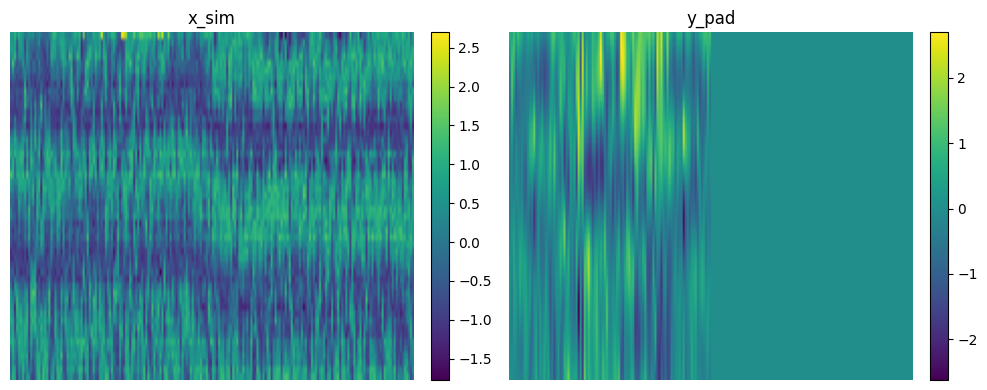

In [13]:
loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_variable, drop_last=False)

# Model
#sde = LinearSDE(state_size=state_size, brownian_size=brownian_size).to(device)
ts_pad, y_pad, mask, x0 = next(iter(loader))
x_sim = torchsde.sdeint(sde, x0, ts_pad, method=method, dt=dt_num).transpose(0, 1)
loss = masked_mse(x_sim, y_pad, mask)
print(loss.item())

x_data = [x_sim.detach().numpy()[0], y_pad.detach().numpy()[0]]
titles = ["x_sim", "y_pad"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, arr, title in zip(axes, x_data, titles):
    im = ax.imshow(arr, aspect="auto")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [14]:
%%timeit
ts_pad, y_pad, mask, x0 = next(iter(loader))
x_sim = torchsde.sdeint(sde, x0, ts_pad, method=method, dt=dt_num).transpose(0, 1)

184 ms ± 2.07 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [15]:
# Data
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_variable, drop_last=False)
set_seed(123)
optimizer = optim.Adam(sde.parameters(), lr=lr)

best_loss = float('inf')
best_model_state = None
# Training loop
for epoch in range(epochs):
    sde.train()
    total_loss = 0.0
    n_batches = 0

    for ts_pad, y_pad, mask, x0 in loader:
        # ts_pad: (T_max,), y_pad: (B, T_max, d), mask: (B, T_max), x0: (B, d)
        ts_pad = ts_pad.to(device)
        y_pad = y_pad.to(device)
        mask = mask.to(device)
        x0 = x0.to(device)

        optimizer.zero_grad()

        # sdeint expects state shape (B, d); returns (T, B, d)
        x_sim = torchsde.sdeint(sde, x0, ts_pad, method=method, dt=dt_num)  # (T_max, B, d)
        x_sim = x_sim.transpose(0, 1)  # (B, T_max, d)
        if torch.any(torch.isnan(x_sim)):
            print("NaN encountered in simulation!")
            continue

        loss = masked_mse(x_sim, y_pad, mask)
        loss.backward()
        #torch.nn.utils.clip_grad_norm_(sde.parameters(), max_norm=10.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    avg_loss = total_loss / max(1, n_batches)
    # Save model weights if loss improved
    print(f"Epoch {epoch:03d} | train loss: {avg_loss:.6f}")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_state = {
            'epoch': epoch,
            'model_state_dict': sde.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss
        }
        

Epoch 000 | train loss: 0.709836
Epoch 001 | train loss: 0.713169
Epoch 002 | train loss: 0.713133
Epoch 003 | train loss: 0.712372
Epoch 004 | train loss: 0.710191
Epoch 005 | train loss: 0.711223
Epoch 006 | train loss: 0.715396
Epoch 007 | train loss: 0.710525
Epoch 008 | train loss: 0.716490
Epoch 009 | train loss: 0.709406
Epoch 010 | train loss: 0.714181
Epoch 011 | train loss: 0.712860
Epoch 012 | train loss: 0.713954
Epoch 013 | train loss: 0.714007
Epoch 014 | train loss: 0.711238
Epoch 015 | train loss: 0.711357
Epoch 016 | train loss: 0.710884
Epoch 017 | train loss: 0.709878
Epoch 018 | train loss: 0.712237
Epoch 019 | train loss: 0.710312


In [16]:
sde.load_state_dict(best_model_state['model_state_dict'])

<All keys matched successfully>

In [37]:
# Data
dataset = VariableLengthSDEData(dt=dt, length=200, device=device, size=size)
loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_variable, drop_last=False)

0.7653515338897705


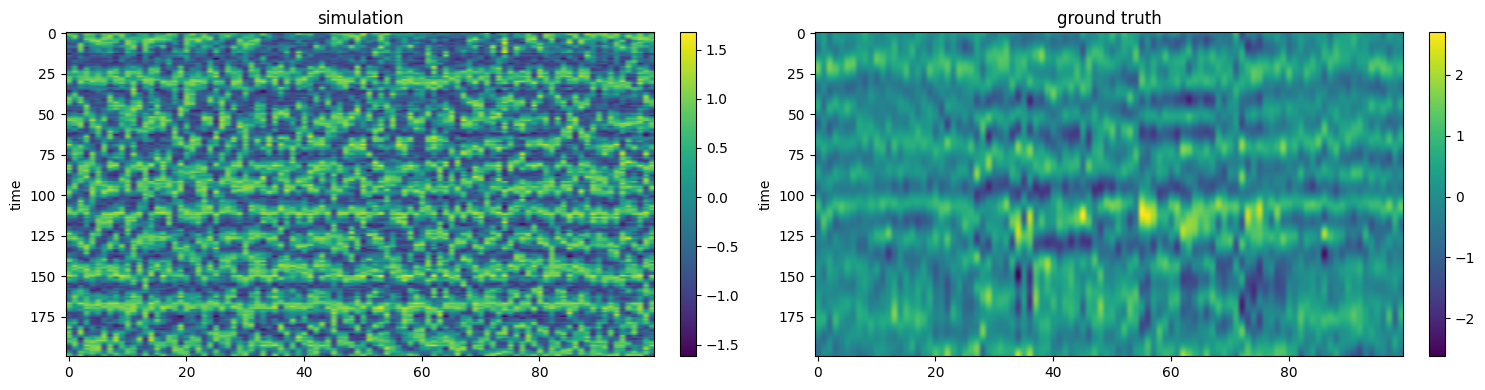

In [38]:
ts_pad, y_pad, mask, x0 = next(iter(loader))
x_sim = torchsde.sdeint(sde, x0, ts_pad, method=method, dt=dt_num).transpose(0, 1)
loss = masked_mse(x_sim, y_pad, mask)
print(loss.item())

x_data = [x_sim.detach().numpy()[0, :,:num_osc], y_pad.detach().numpy()[0, :, :num_osc]]
titles = ["simulation", "ground truth"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, arr, title in zip(axes, x_data, titles):
    im = ax.imshow(arr, aspect="auto")
    ax.set_title(title)
    #ax.set_xticks(range(len(atlas["labels"])))
    ax.set_ylabel("time")
    #ax.set_xticklabels(atlas["labels"], rotation=45, ha="right")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [39]:
from torchsde import BrownianInterval
t, y_pad, mask, x0 = next(iter(loader))

n_samples = 5

x0_batch = x0.repeat(n_samples, 1)
bm = BrownianInterval(t0=t[0], t1=t[-1], size=(n_samples, brownian_size), device=device, dt=dt, levy_area_approximation="space-time")

y_sim = torchsde.sdeint(sde, x0_batch, t, bm=bm, dt=dt_num)
ys = y_sim.detach().numpy()

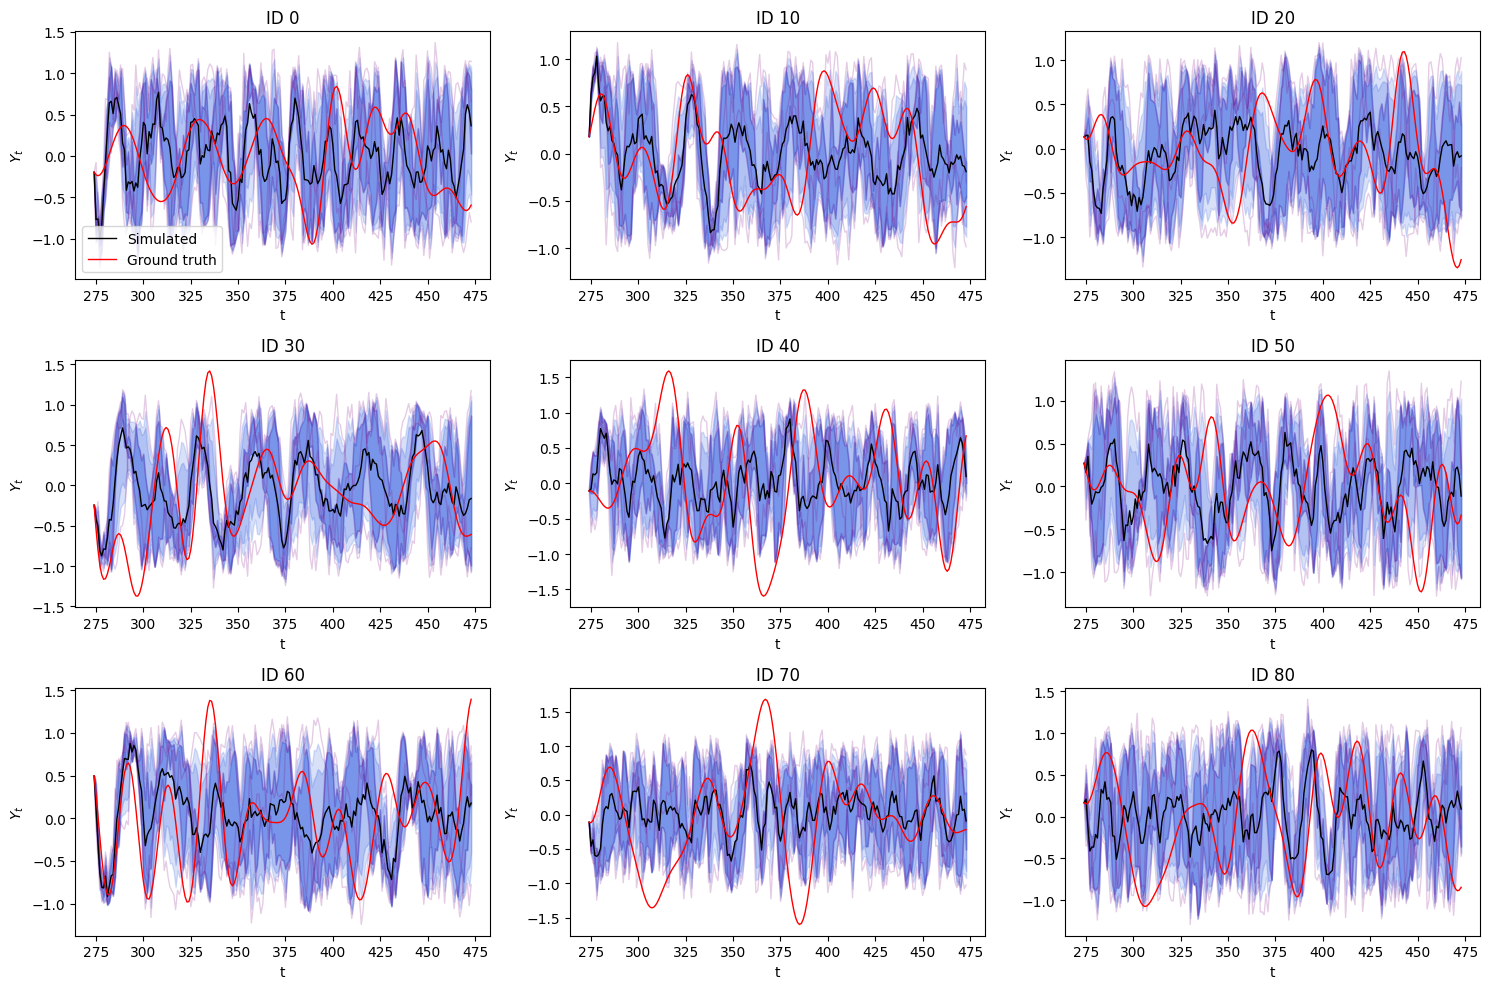

In [40]:
# Mean and quantiles
ids = np.arange(0, 90, 10)
n_rows, n_cols = 3, 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15,10), squeeze=False)
    
for i, id_val in enumerate(ids):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]
    
    # Mean and quantiles
    yi = ys[:, :, id_val].transpose(1,0)
    mean = yi.mean(axis=0)
    q5, q10, q25, q75, q90, q95 = np.percentile(yi, [5, 10, 25, 75, 90, 95], axis=0)
    
    # Fill areas
    ax.fill_between(t, q5, q95, color="royalblue", alpha=0.2)
    ax.fill_between(t, q10, q90, color="royalblue", alpha=0.25)
    ax.fill_between(t, q25, q75, color="royalblue", alpha=0.5)
    
    # Sample paths
    for j in range(n_samples):
        ax.plot(t, yi[j], color="purple", alpha=0.2, linewidth=1)
    
    # Mean and ground truth
    ax.plot(t, mean, color="black", linewidth=1, label="Simulated")
    ax.plot(t, y_pad[0, :, id_val].numpy(), color="red", linewidth=1, label="Ground truth")
    
    ax.set_title(f"ID {id_val}")
    ax.set_xlabel("t")
    ax.set_ylabel(r"$Y_t$")
    if i == 0:  # Legend only on first subplot
        ax.legend()

# Hide unused subplots
for i in range(len(ids), n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()

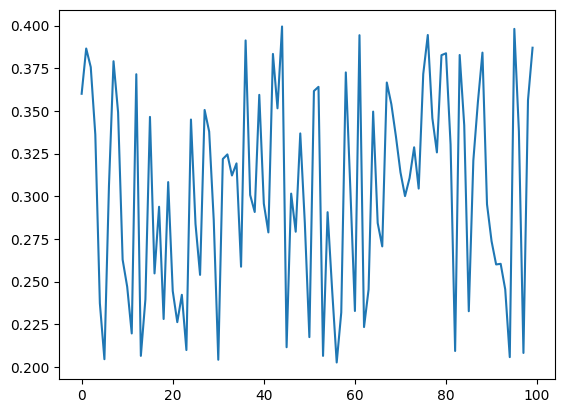

In [41]:
plt.plot(sde.omega.detach().cpu().numpy())

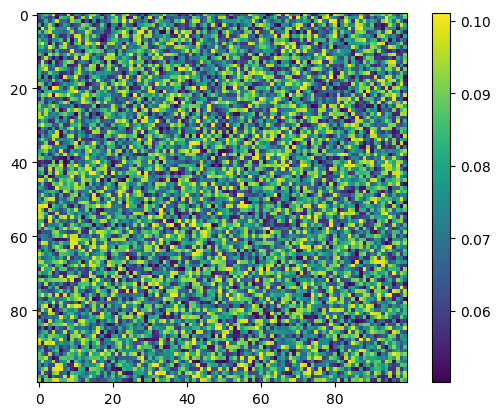

In [22]:
plt.imshow(sde.C.detach().cpu().numpy(), cmap='viridis')
plt.colorbar()

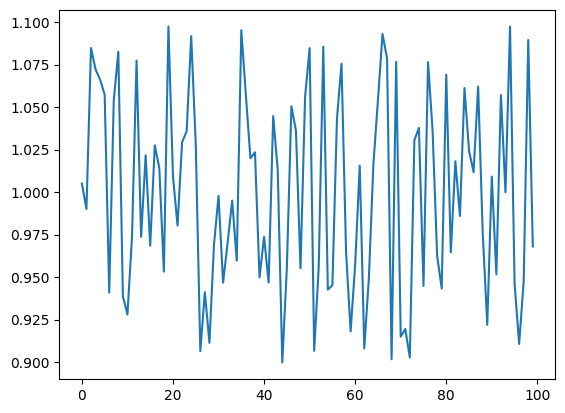

In [23]:
plt.plot(sde.a.detach().cpu().numpy())

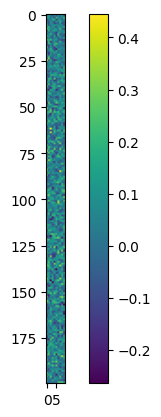

In [24]:
plt.imshow(sde.B.detach().cpu().numpy(), cmap='viridis')
plt.colorbar()

In [25]:
def masked_mse_axis(pred, target, mask):
    # pred, target: (B, T, d); mask: (B, T)
    diff = (pred - target) ** 2  # (B, T, d)
    diff = diff * mask           # zero out padded steps
    # average over valid elements only
    return diff.mean(axis=0)

In [26]:
error_result = masked_mse_axis(y_sim.transpose(0,1), y_pad,mask)

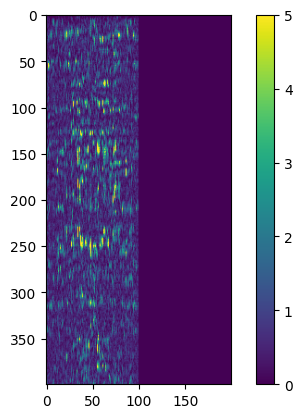

In [27]:
fig, ax = plt.subplots()
im = ax.imshow(error_result.detach().numpy(), vmax=5)
cbar = plt.colorbar(im, ax=ax)
plt.show()